## Explainable AI: SHAP and LIME for a decision-support forecast

The forecasting model produces a 120-hour price profile for DK1. The recommendation layer then translates that forecast profile into consumption advice: whether a household should consume energy now to avoid an expensive period or wait for a cheaper window. Explainable AI sits between these two steps. Its purpose is to analyse which input variables are driving the predicted prices and how. It is then fed into the LLM recommendation layer to make meaningfull and trustworthy reasoning.

In [6]:
import joblib

from src.analysis.explainable_ai import (
    OUTPUT_DIR,
    make_dashboard_lime_summary,
    make_dashboard_shap_summary,
    plot_feature_importance,
    plot_lime_explanations,
    plot_shap_explanations,
)

final_models = joblib.load(OUTPUT_DIR / "final_day_models.joblib")



We start with XGBoost feature importance as a coarse global view. The model is split into five day-specific regressors, so the plot shows whether the short-horizon and long-horizon forecasts depend on similar drivers or whether the dominant predictors change across the 120-hour forecast window.


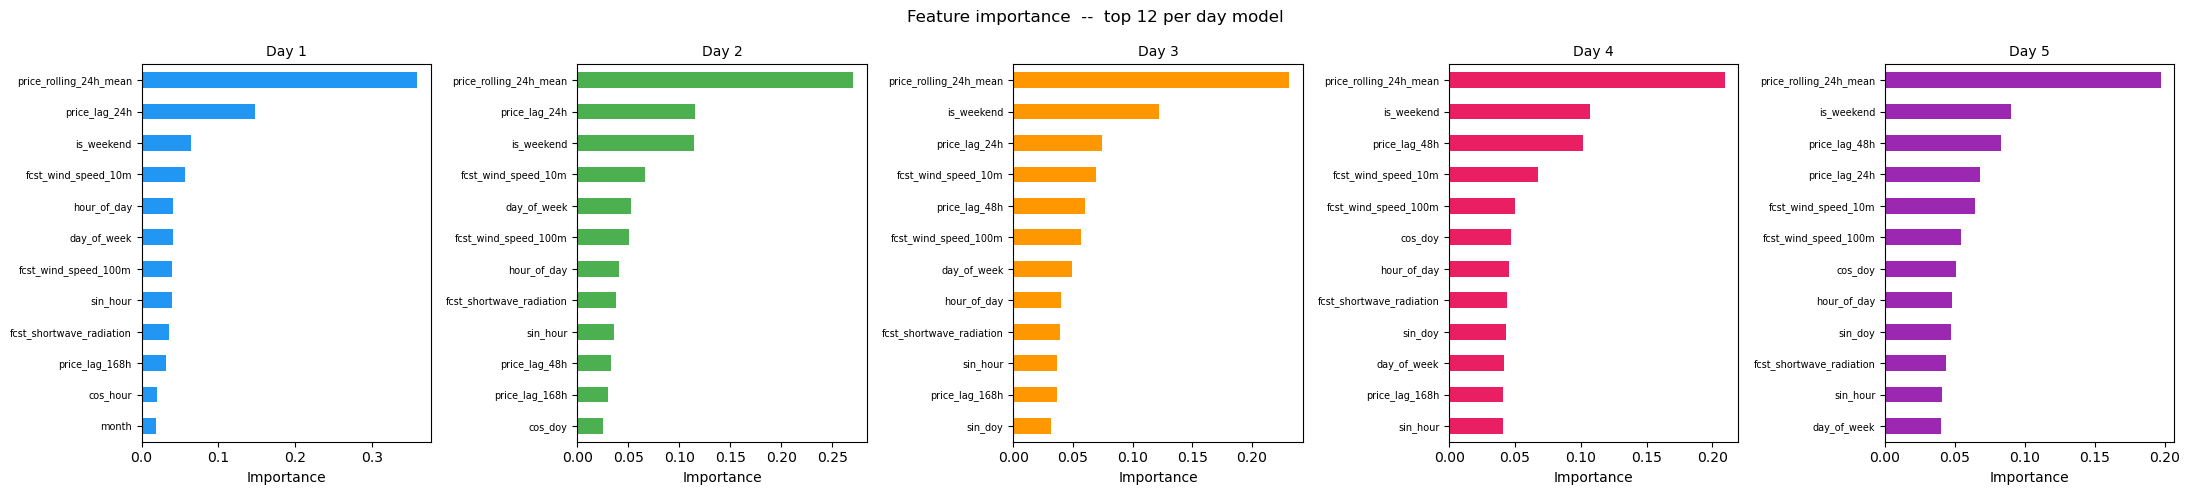

In [7]:
plot_feature_importance(final_models)

Across all five day-specific models, the rolling 24-hour mean price is the most important feature by a large margin. This means that the forecast is anchored heavily in the recent price level: if prices have been high during the last day, the model tends to expect elevated prices to continue, and if prices have recently been low, the forecast is pulled downward. This is a plausible result for electricity price forecasting. Day-ahead prices are not random from hour to hour; they often move in regimes where fuel prices, wind conditions, demand, imports/exports, and market expectations keep prices elevated or depressed for several consecutive hours or days. The model therefore appears to learn a meaningful persistence effect rather than relying only on weather forecasts.

Weather variables, especially fcst_wind_speed_10m and fcst_wind_speed_100m, appear among the top predictors across the forecast window, but they have lower importance than recent price features. This suggests that weather forecasts refine the price forecast around a baseline mainly set by recent market behaviour.

There is also a visible horizon effect. For Day 1, the model relies strongly on price_lag_24h, meaning yesterday’s mean price is highly informative for the next 24 hours. From Day 3 onward, price lags such as price_lag_24h, price_lag_48h, and price_lag_168h become more visible. This makes intuitive sense: as the forecast horizon expands, the exact price level from yesterday becomes less directly useful, while weekly seasonality and broader price regimes become more relevant. The increasing role of is_weekend, day_of_week, and time-cycle variables also supports this interpretation.

Feature importance is useful as an entry point, but it does not show whether a feature pushes the forecast up or down. It can also blur correlated drivers. We therefore use SHAP as the main global explanation method. SHAP decomposes each forecast into additive feature contributions, which is useful when the dashboard recommends a timing decision and we want to understand why a cheap or expensive window appears in the forecast.

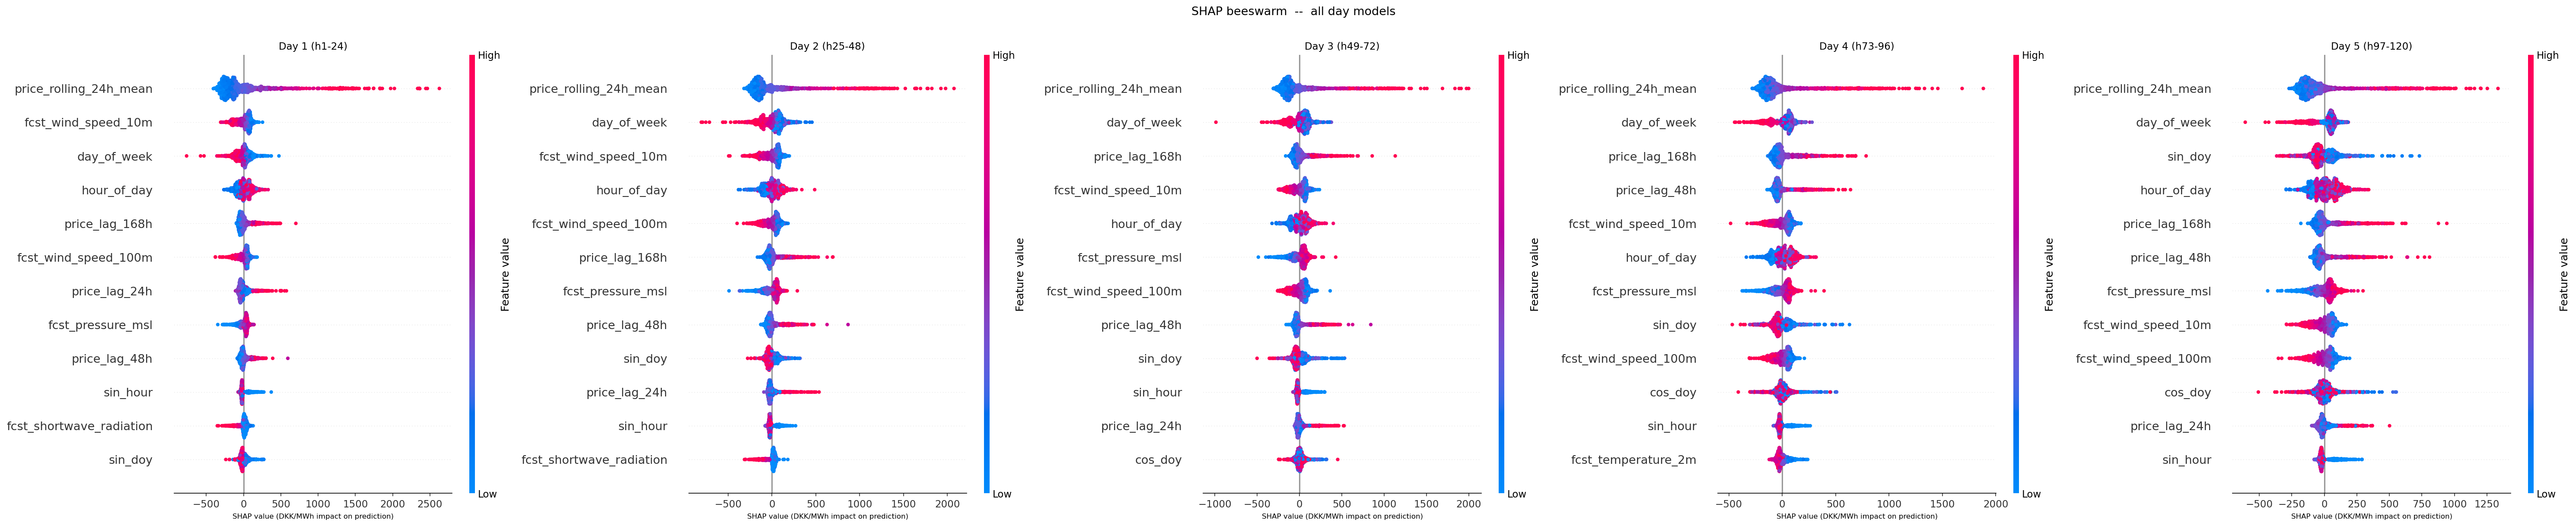

In [8]:
plot_shap_explanations(width=1200)

The SHAP beeswarm plot gives a more detailed view of how the model uses each feature across many forecasts. Each point represents one forecasted hour, where the horizontal position shows whether the feature pushed the prediction up or down. The colour shows the feature value: red points are high feature values and blue points are low feature values.

The clearest pattern is again that price_rolling_24h_mean dominates the forecast across all five days. High recent average prices, shown by red points, are mostly placed on the positive side of the SHAP axis. This means that when the recent 24-hour price level is high, the model generally pushes the forecast upward. Low recent prices, shown by blue points, are mostly on the negative side, meaning that they pull the forecast downward. This is one of the most interpretable results in the Explainable AI section: the model has learned price persistence in a very direct way. The beeswarm plot also shows that this persistence effect remains important throughout the full 120-hour horizon, although the spread becomes smaller toward Day 5.

Several lagged price variables show similar, but weaker, effects. price_lag_168h becomes especially visible from Day 3 onward, indicating that the model uses prices from the same time one week earlier as a longer-horizon reference point. This supports the idea that the model combines short-term price persistence with weekly market patterns.

Wind variables also matter. For both fcst_wind_speed_10m and fcst_wind_speed_100m, lower wind values are often associated with positive SHAP values, meaning they push the predicted price upward. Higher wind values more often appear on the negative side, meaning they pull the predicted price downward. This fits the DK1 market logic: when wind conditions are weak, less wind generation is expected and price pressure can increase; when wind conditions are strong, higher renewable supply can help reduce prices.

Calendar variables such as day_of_week, hour_of_day, sin_doy, cos_doy, and sin_hour become more visible in the later horizons. These features capture recurring daily and weekly patterns rather than specific market shocks. Their importance supports the interpretation that, as the forecast moves further away from the present, the model relies more on regular time structure and less on very recent price observations.

For the project objective, households do not need to read feature importance plots or beeswarm SHAP plots before using the app. The SHAP values are used as input for the dashboard LLM recommendation layer. Thereby it allows it to analyse the relationship between the forecast predictions and the predictors because  recommendation to e.g. wait should be traceable to sensible drivers such as renewable availability, recent price persistence, demand-sensitive weather, or time-of-day effects.

In [9]:
dashboard_shap_context = (
    make_dashboard_shap_summary(top_n=8)
    .loc[:, [
        "display_feature",
        "mean_abs_shap_dkk_kwh",
        "low_value_mean_shap_dkk_kwh",
        "high_value_mean_shap_dkk_kwh",
        "low_value_pressure",
        "high_value_pressure",
        "direction_summary",
    ]]
    .rename(columns={
        "display_feature": "feature",
        "mean_abs_shap_dkk_kwh": "global_strength_dkk_kwh",
        "low_value_mean_shap_dkk_kwh": "low_values_push_dkk_kwh",
        "high_value_mean_shap_dkk_kwh": "high_values_push_dkk_kwh",
    })
)

dashboard_shap_context.style.format(
    {
        "global_strength_dkk_kwh": "{:.4f}",
        "low_values_push_dkk_kwh": "{:+.4f}",
        "high_values_push_dkk_kwh": "{:+.4f}",
    }
)


,feature,global_strength_dkk_kwh,low_values_push_dkk_kwh,high_values_push_dkk_kwh,low_value_pressure,high_value_pressure,direction_summary
0,Recent 24h price average,0.2830,-0.2723,+0.6113,lowers predicted prices,raises predicted prices,high values push prices higher than low values
1,Forecast wind speed 10m,0.0749,+0.0910,-0.1292,raises predicted prices,lowers predicted prices,low values push prices higher than high values
2,Day of week,0.0726,+0.1022,-0.1079,raises predicted prices,lowers predicted prices,low values push prices higher than high values
3,Hour of day,0.0662,-0.0815,+0.0855,lowers predicted prices,raises predicted prices,high values push prices higher than low values
4,Price 168h ago,0.0597,-0.0497,+0.1398,lowers predicted prices,raises predicted prices,high values push prices higher than low values
5,Forecast wind speed 100m,0.0564,+0.0580,-0.1033,raises predicted prices,lowers predicted prices,low values push prices higher than high values
6,Price 24h ago,0.0520,+0.0319,+0.0489,raises predicted prices,raises predicted prices,high values push prices higher than low values
7,Price 48h ago,0.0438,-0.0366,+0.1074,lowers predicted prices,raises predicted prices,high values push prices higher than low values


The table above is the Day 1 SHAP export that is loaded by `dashboard.py` from `outputs/model/shap_day1_values.parquet` and `outputs/model/shap_day1_features.parquet`. 

The LLM prompt receives a compressed text version of the same global model diagnostics.

The global model diagnostics compares the mean SHAP effect in the lower and upper feature-value quantiles. This preserves the beeswarm interpretation in a table-friendly form: for wind, low wind values tend to push prices upward while high wind values tend to pull prices downward.

In the LLM prompt, this becomes a small `MODEL DIAGNOSTICS` block. It is explicitly labelled as secondary evidence about what the XGBoost model has learned, not as causal truth. The LLM is instructed to prefer the actual forecast, intraday price pattern, and weather data whenever they conflict with the attribution summary. This turns SHAP into a communication layer: it helps the generated explanation stay connected to recognizable market drivers without making Explainable AI the only basis for the recommendation.


Loading model-ready dataset...
  463,784 rows | region=DK1_west
  After feature NaN drop: 463,784 rows
  Usable range: 2021-01-08 to 2026-04-24
  fig7 saved


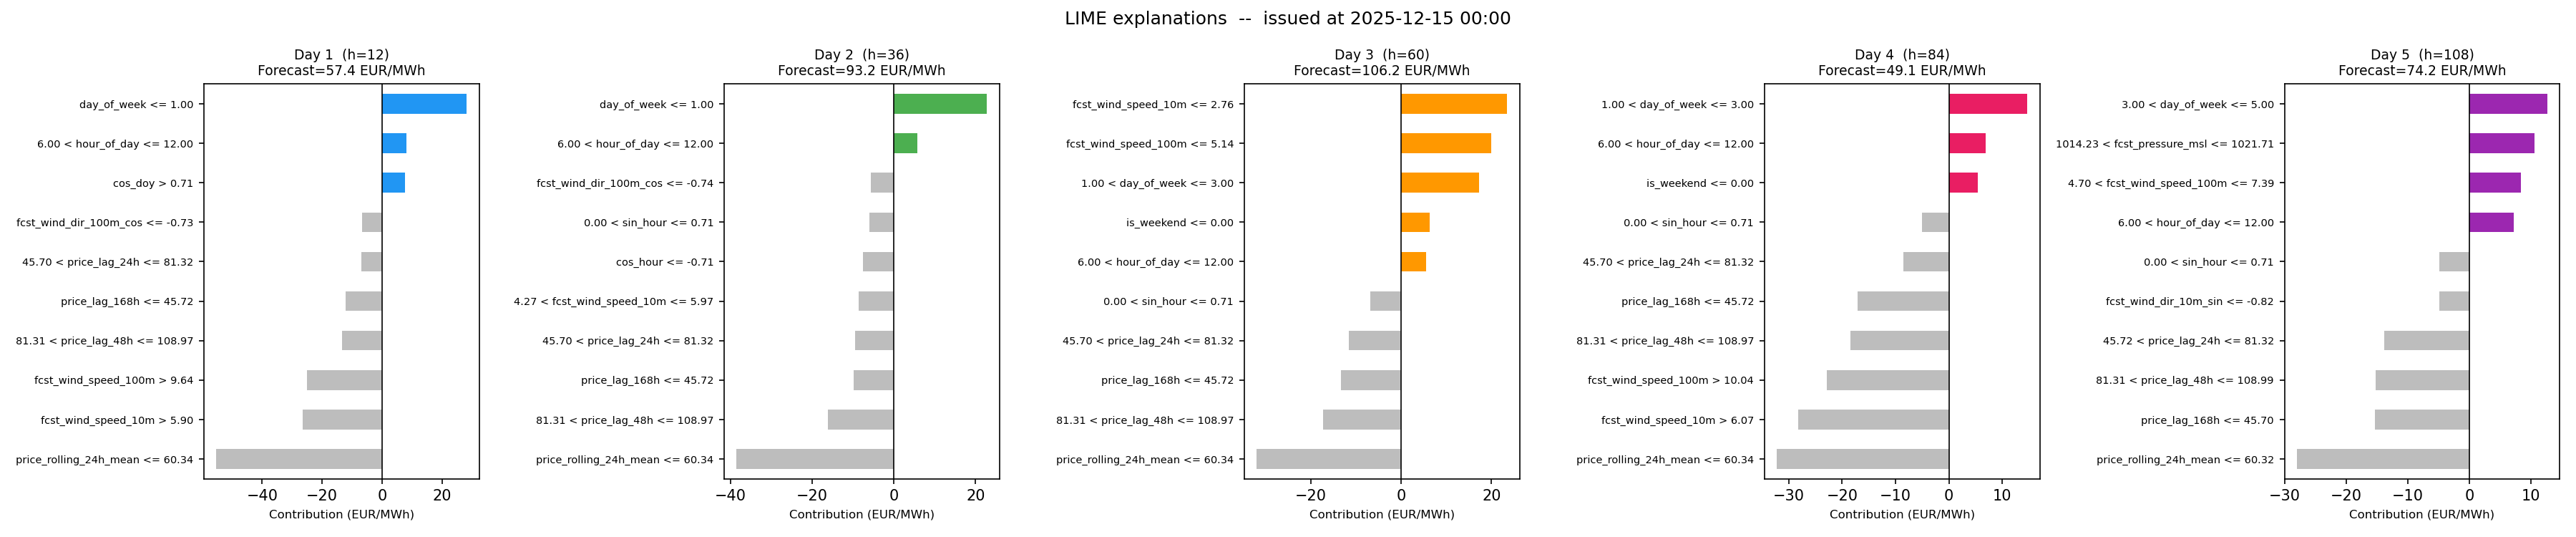

In [10]:
plot_lime_explanations(width=1200)

LIME complements SHAP by focusing on one concrete forecast issue time. It fits a simple local surrogate around the selected forecast instance and shows which features pushed that specific prediction upward or downward. In other words, SHAP answers **"what generally drives this model?"**, while LIME helps answer **"why did the model make this recommendation now?"**

This local view is important for a consumer recommendation system because the same global model can produce different advice on different days. On one day, the recommended cheap window may be explained by strong wind and low recent prices. On another, a warning to consume earlier may be explained by lower renewable availability, higher lagged prices, and a peak-hour calendar effect.

The dashboard uses this idea in a deliberately narrow way. It does not send LIME explanations for all 120 forecast hours. Instead, it identifies the cheapest rolling 3-hour window and the most expensive rolling 3-hour window, then explains one representative hour inside each window. This keeps local Explainable AI focused on the actual decision points: when to shift flexible demand, and when to avoid consumption.


In [11]:
dashboard_lime_context = make_dashboard_lime_summary(final_models, top_n=4)
dashboard_lime_context[
    [
        "window_label",
        "window_start",
        "window_end",
        "window_avg_dkk_kwh",
        "representative_time",
        "horizon_h",
        "feature_rule",
        "direction",
        "contribution_dkk_kwh",
    ]
].style.format(
    {
        "window_start": lambda x: x.strftime("%a %d %b %H:%M"),
        "window_end": lambda x: x.strftime("%a %d %b %H:%M"),
        "window_avg_dkk_kwh": "{:.3f}",
        "representative_time": lambda x: x.strftime("%a %d %b %H:%M"),
        "contribution_dkk_kwh": "{:+.4f}",
    }
)


,window_label,window_start,window_end,window_avg_dkk_kwh,representative_time,horizon_h,feature_rule,direction,contribution_dkk_kwh
0,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,60.91 < Recent 24h price average <= 87.96,lowers forecast,-0.2116
1,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,Forecast wind speed 10m > 6.16,lowers forecast,-0.1649
2,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,47.12 < Price 168h ago <= 81.60,lowers forecast,-0.1628
3,Cheapest selected window,Sat 11 Apr 13:00,Sat 11 Apr 16:00,0.017,Sat 11 Apr 14:00,98,Day-of-year cycle sine > 0.75,lowers forecast,-0.1243
4,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,60.29 < Recent 24h price average <= 87.50,lowers forecast,-0.3211
5,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,Forecast wind speed 10m <= 2.84,raises forecast,+0.1620
6,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,Price 48h ago <= 45.72,lowers forecast,-0.1359
7,Most expensive selected window,Tue 07 Apr 19:00,Tue 07 Apr 22:00,0.875,Tue 07 Apr 20:00,8,Day of week <= 1.00,raises forecast,+0.1154


The table above mirrors the local LIME information passed to the dashboard LLM. Each row is one local contribution for a representative forecast hour inside either the selected cheap window or the selected expensive window. Positive contributions raise the local price forecast; negative contributions lower it. This is why LIME is useful for the dashboard's household guidance: it can explain why the current recommendation window looks cheap or risky without flooding the prompt with attribution values for every hour.

The dashboard computes this local attribution with `final_day_models.joblib` and matching rows from `data/model_dataset.parquet`. For historical issue dates from the walk-forward prediction file, the LIME values should therefore be read as a local diagnostic for the final model family, not as a perfect audit trail of the exact fold model that produced every stored prediction. This is another reason the LLM receives the diagnostics as secondary evidence rather than as the sole explanation.

This also matters for the final impact analysis. The shifting simulation estimates what happens when households react to forecast-based recommendations. Explainable AI does not prove that the behavioral impact will occur, but it makes the mechanism more credible: the simulated shifts are based on price signals that can be inspected and related back to recognizable market drivers. If the impact model shows large benefits while SHAP or LIME reveals that the forecast signal is driven by an implausible artifact, that would be a warning sign before interpreting the resilience contribution.
